# Few-Shot Learning on Perch V2 Bioacoustic Embeddings

This notebook evaluates **few-shot learning** on dolphin whistle / background embeddings extracted with Google's Perch V2 model. The goal is to determine the minimum number of labeled samples needed to approach fully supervised performance.

Fully supervised training happens with max 805 samples per class, so our max shot value will be 805
### Strategy
- **Algorithms:** Logistic Regression · Decision Tree · Random Forest · SVM (RBF) · Nearest Centroid
- **Shot sizes:** 4, 8, 16, 32, 64, 128, 256, 512, 805 labeled examples *per class*
- **Repetitions:** 10 random seeds per shot size (to measure variance from sampling)
- **Test set:** All remaining data not used for training (≥126 samples per class even at 1024-shot)
- **Preprocessing:** L2-normalised embeddings, StandardScaler fitted on train split only
- **Baseline:** Fully supervised classifiers trained on 70/30 stratified split (loaded from CSV for comparison)

### Why these five?
| Model | Why it's included |
|---|---|
| Logistic Regression | Linear probe, strong regularisation, standard baseline for transfer learning |
| Decision Tree | Simple non-linear model, matches fully supervised setup |
| Random Forest | Ensemble of trees, robust to noise, matches fully supervised setup |
| SVM (RBF) | Maximises margin — top performer in fully supervised, tests if it holds with fewer samples |
| Nearest Centroid | Computes a class prototype (mean embedding) — zero fitting, mirrors Perch design intent |

### Key questions
1. How many labeled samples per class are needed to reach **90%** of fully supervised AUC?
2. At what point do **diminishing returns** set in — where doubling labels barely improves performance?
3. Which classifier is **most sample-efficient** — reaching high performance with the fewest labels?

## 0 · Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, time
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedShuffleSplit

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All imports OK.')

All imports OK.


## 1 · Load Data

In [2]:
BASE = '/data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE'

X = np.load(f'{BASE}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_raw = np.load(f'{BASE}/embeddings/y_labels.npy')   # (9209,)
meta = pd.read_csv(f'{BASE}/embeddings/metadata.csv')

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_

print(f'Embeddings : {X.shape}')
print(f'Labels     : {y.shape}  → classes: {classes}')
print(f'Class distribution:')
for cls, idx in zip(classes, range(len(classes))):
    print(f'  [{idx}] {cls:20s}  n={np.sum(y == idx)}')

Embeddings : (3290, 1536)
Labels     : (3290,)  → classes: ['background' 'whistle']
Class distribution:
  [0] background            n=2140
  [1] whistle               n=1150


## 2 · Normalise Embeddings

L2-normalise so that distances in embedding space are meaningful for Nearest Centroid, and to put LR / SVM on equal footing. This is the standard practice for frozen Perch embeddings.

In [3]:
norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / np.clip(norms, 1e-8, None)
print(f'Embeddings L2-normalised. Mean norm after: {np.linalg.norm(X_norm, axis=1).mean():.4f}')

Embeddings L2-normalised. Mean norm after: 1.0000


## 3 · Few-Shot Evaluation Framework

In [43]:
#@title Few-shot learning — comparable to fully supervised classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from collections import defaultdict
import numpy as np
import time

# ── Classifier factory — matches fully supervised classifiers ─────────────────
def make_classifiers():
    return {
        'Logistic Regression': LogisticRegression(
            C=1.0, max_iter=1000, solver='lbfgs',
            class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=RANDOM_SEED, n_jobs=-1
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', C=1.0, gamma='scale',
            probability=True, class_weight='balanced', random_state=RANDOM_SEED
        ),
        'Nearest Centroid': NearestCentroid(metric='euclidean'),
    }

# ── Single few-shot trial ─────────────────────────────────────────────────────
def run_trial(X_all, y_all, n_shots, seed, classifiers):
    """
    Sample n_shots per class as train, rest as test.
    Preserves class ratio in both splits by sampling equally per class.
    """
    rng = np.random.RandomState(seed)
    classes = np.unique(y_all)
    class_counts = np.array([np.sum(y_all == c) for c in classes])
    
    # Compute per-class train sizes proportional to class distribution
    # Total training samples = n_shots * n_classes (for backward compatibility)
    total_train = n_shots * len(classes)
    class_ratios = class_counts / class_counts.sum()
    train_per_class = np.round(class_ratios * total_train).astype(int)
    
    # Ensure we don't exceed class size (leave at least 10% for test)
    max_per_class = (class_counts * 0.9).astype(int)
    train_per_class = np.minimum(train_per_class, max_per_class)

    train_idx, test_idx = [], []
    for cls, n_train in zip(classes, train_per_class):
        cls_idx = np.where(y_all == cls)[0]
        chosen = rng.choice(cls_idx, size=n_train, replace=False)
        train_idx.extend(chosen)
        test_idx.extend([i for i in cls_idx if i not in set(chosen)])

    train_idx = np.array(train_idx)
    test_idx = np.array(test_idx)

    # Scale — fit on train only
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_all[train_idx])
    X_te = scaler.transform(X_all[test_idx])
    y_tr = y_all[train_idx]
    y_te = y_all[test_idx]

    results = {}
    for name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        if hasattr(clf, 'predict_proba'):
            y_score = clf.predict_proba(X_te)[:, 1]
        elif hasattr(clf, 'decision_function'):
            y_score = clf.decision_function(X_te)
        else:
            y_score = y_pred.astype(float)

        results[name] = {
            'accuracy': accuracy_score(y_te, y_pred),
            'macro_f1': f1_score(y_te, y_pred, average='macro'),
            'roc_auc': roc_auc_score(y_te, y_score),
            'time_s': time.time() - t0,
        }
    return results

print('Framework defined.')
print(f'\nClass distribution:')
for cls, idx in zip(classes, range(len(classes))):
    count = np.sum(y == idx)
    ratio = count / len(y)
    print(f'  [{idx}] {cls:20s}  n={count}  ratio={ratio:.3f}')

Framework defined.

Class distribution:
  [0] background            n=2140  ratio=0.650
  [1] whistle               n=1150  ratio=0.350


In [44]:
min_class = min(np.sum(y == c) for c in range(len(classes)))
print(f'Min class size: {min_class}')

for s in [4, 8, 16, 32, 64, 128, 256, 512, 805]:
    test_per_class = min_class - s
    total_test = sum(np.sum(y == c) - s for c in range(len(classes)))
    print(f'  {s:>5d}-shot → {test_per_class:>5d} test samples in smallest class, {total_test:>5d} total test')

Min class size: 1150
      4-shot →  1146 test samples in smallest class,  3282 total test
      8-shot →  1142 test samples in smallest class,  3274 total test
     16-shot →  1134 test samples in smallest class,  3258 total test
     32-shot →  1118 test samples in smallest class,  3226 total test
     64-shot →  1086 test samples in smallest class,  3162 total test
    128-shot →  1022 test samples in smallest class,  3034 total test
    256-shot →   894 test samples in smallest class,  2778 total test
    512-shot →   638 test samples in smallest class,  2266 total test
    805-shot →   345 test samples in smallest class,  1680 total test


## 4 · Run Experiments

10 random seeds × 8 shot sizes × 5 classifiers (~5 mins to run)

In [45]:
SHOT_SIZES = [4, 16, 32, 64, 128, 256, 512, 805]
N_TRIALS = 10
SEEDS = list(range(N_TRIALS))

records = defaultdict(lambda: defaultdict(list))

for n_shots in SHOT_SIZES:
    print(f'\n── {n_shots}-shot ({n_shots * len(classes)} total training samples) ──')
    for seed in SEEDS:
        clfs = make_classifiers()
        trial_results = run_trial(X_norm, y, n_shots, seed, clfs)
        for clf_name, metrics in trial_results.items():
            records[n_shots][clf_name].append(metrics)
        print(f'  seed {seed:2d} | '
              + ' | '.join(
                  f"{n}: AUC={trial_results[n]['roc_auc']:.3f}"
                  for n in trial_results
              ))

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '=' * 120)
print('FEW-SHOT SUMMARY — Mean ± Std ROC AUC over 10 trials')
print('=' * 120)

clf_names = list(make_classifiers().keys())
header = f'{"Shots":>6} |' + '|'.join(f' {n:^25s}' for n in clf_names) + '|'
print(header)
print('-' * len(header))

for n_shots in SHOT_SIZES:
    row = f'{n_shots:>6} |'
    for clf_name in clf_names:
        aucs = [r['roc_auc'] for r in records[n_shots][clf_name]]
        row += f' {np.mean(aucs):.3f} ± {np.std(aucs):.3f}            |'
    print(row)

print('\n Few-shot experiments complete.')


── 4-shot (8 total training samples) ──
  seed  0 | Logistic Regression: AUC=0.885 | Decision Tree: AUC=0.486 | Random Forest: AUC=0.910 | SVM (RBF): AUC=0.116 | Nearest Centroid: AUC=0.916
  seed  1 | Logistic Regression: AUC=0.936 | Decision Tree: AUC=0.496 | Random Forest: AUC=0.934 | SVM (RBF): AUC=0.926 | Nearest Centroid: AUC=0.900


  seed  2 | Logistic Regression: AUC=0.927 | Decision Tree: AUC=0.497 | Random Forest: AUC=0.887 | SVM (RBF): AUC=0.892 | Nearest Centroid: AUC=0.865
  seed  3 | Logistic Regression: AUC=0.855 | Decision Tree: AUC=0.504 | Random Forest: AUC=0.866 | SVM (RBF): AUC=0.111 | Nearest Centroid: AUC=0.890
  seed  4 | Logistic Regression: AUC=0.930 | Decision Tree: AUC=0.653 | Random Forest: AUC=0.928 | SVM (RBF): AUC=0.923 | Nearest Centroid: AUC=0.881
  seed  5 | Logistic Regression: AUC=0.940 | Decision Tree: AUC=0.577 | Random Forest: AUC=0.931 | SVM (RBF): AUC=0.931 | Nearest Centroid: AUC=0.896
  seed  6 | Logistic Regression: AUC=0.892 | Decision Tree: AUC=0.781 | Random Forest: AUC=0.861 | SVM (RBF): AUC=0.889 | Nearest Centroid: AUC=0.880
  seed  7 | Logistic Regression: AUC=0.893 | Decision Tree: AUC=0.495 | Random Forest: AUC=0.873 | SVM (RBF): AUC=0.853 | Nearest Centroid: AUC=0.873
  seed  8 | Logistic Regression: AUC=0.922 | Decision Tree: AUC=0.683 | Random Forest: AUC=0.916 | S

## 5 · Aggregate Results

In [49]:
# ── Save raw trial results ────────────────────────────────────────────────────
rows = []
for n_shots in SHOT_SIZES:
    for clf_name in clf_names:
        for trial_idx, metrics in enumerate(records[n_shots][clf_name]):
            rows.append({
                'n_shots': n_shots,
                'classifier': clf_name,
                'trial': trial_idx,
                'accuracy': metrics['accuracy'],
                'macro_f1': metrics['macro_f1'],
                'roc_auc': metrics['roc_auc'],
                'time_s': metrics['time_s'],
            })

fs_df = pd.DataFrame(rows)
fs_df.to_csv(f'{BASE}/few_shot/raw_trials.csv', index=False)
print(f'Raw trials saved → {BASE}/few_shot/raw_trials.csv  ({fs_df.shape})')

# ── Summary with mean ± std ───────────────────────────────────────────────────
summary_df = fs_df.groupby(['n_shots', 'classifier']).agg(
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    macro_f1_mean=('macro_f1', 'mean'),
    macro_f1_std=('macro_f1', 'std'),
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    time_mean=('time_s', 'mean'),
    time_std=('time_s', 'std'),
).reset_index()

summary_df.to_csv(f'{BASE}/few_shot/summary.csv', index=False)
print(f'Summary saved   → {BASE}/few_shot/summary.csv  ({summary_df.shape})')

Raw trials saved → /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/raw_trials.csv  ((400, 7))
Summary saved   → /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/summary.csv  ((40, 10))


## 6 · Visualisations

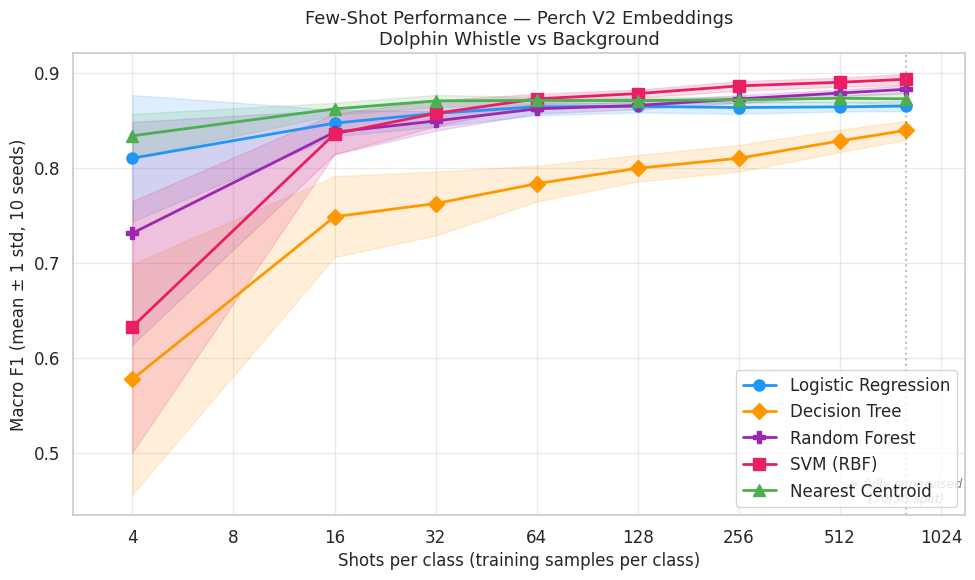

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/f1_curve.png


In [54]:
# ── 6.1  Macro F1 vs Shot Size (mean ± std ribbon) + fully supervised ref ────
CLF_COLORS = {
    'Logistic Regression': '#2196F3',
    'Decision Tree'      : '#FF9800',
    'Random Forest'      : '#9C27B0',
    'SVM (RBF)'          : '#E91E63',
    'Nearest Centroid'   : '#4CAF50',
}


CLF_MARKERS = {
    'Logistic Regression': 'o',
    'Decision Tree'      : 'D',
    'Random Forest'      : 'P',
    'SVM (RBF)'          : 's',
    'Nearest Centroid'   : '^',
}

fig, ax = plt.subplots(figsize=(10, 6))

# Few-shot curves
for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['macro_f1_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    (sub['macro_f1_mean'] - sub['macro_f1_std']).values,
                    (sub['macro_f1_mean'] + sub['macro_f1_std']).values,
                    alpha=0.15, color=color)

# Mark the last shot size as fully-supervised equivalent
ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.01, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('Macro F1 (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('Few-Shot Performance — Perch V2 Embeddings\nDolphin Whistle vs Background', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/f1_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/f1_curve.png')

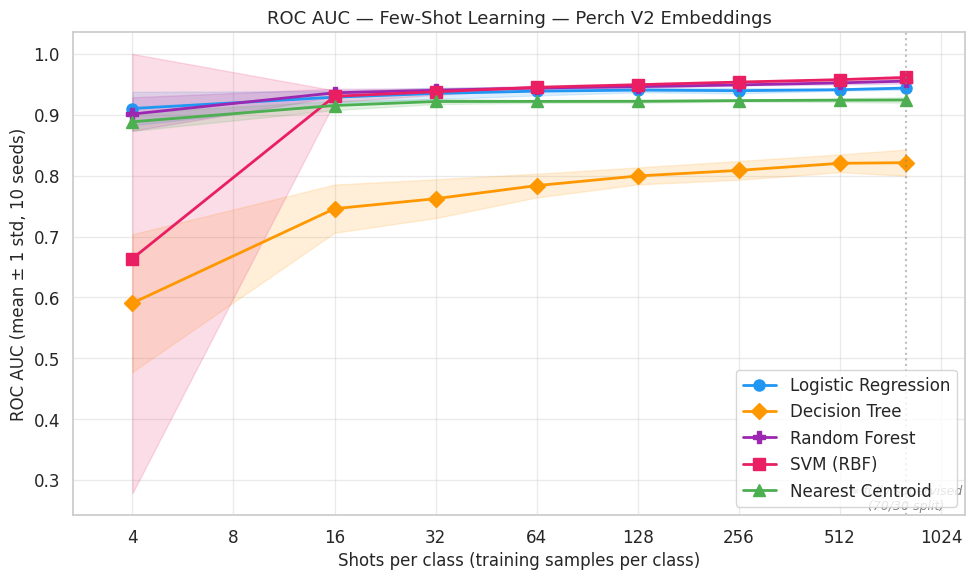

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/auc_curve.png


In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['roc_auc_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    np.clip((sub['roc_auc_mean'] - sub['roc_auc_std']).values, 0, 1),
                    np.clip((sub['roc_auc_mean'] + sub['roc_auc_std']).values, 0, 1),
                    alpha=0.15, color=color)

ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.005, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('ROC AUC (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('ROC AUC — Few-Shot Learning — Perch V2 Embeddings', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_curve.png')

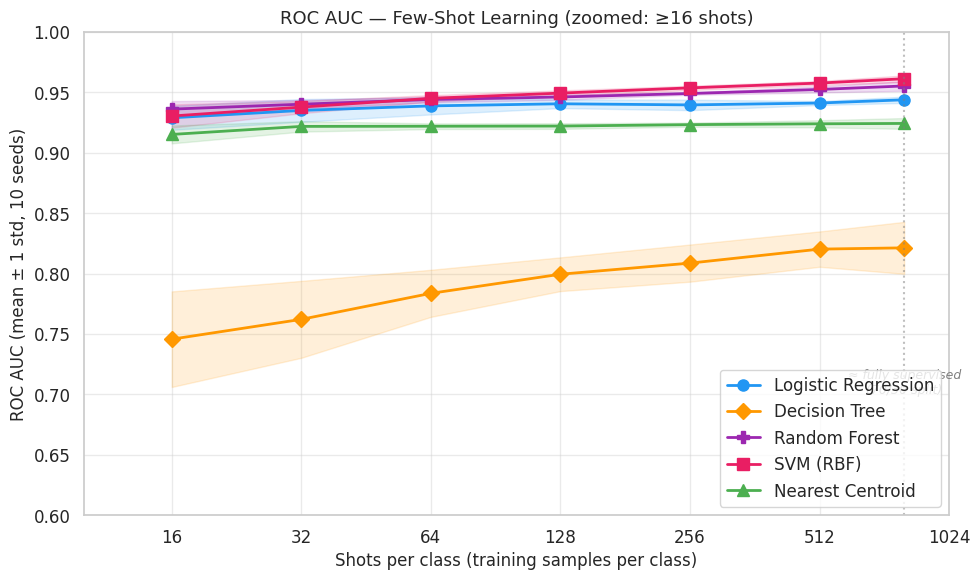

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/auc_curve_zoomed.png


In [61]:
# ── 6.2b  ROC AUC vs Shot Size — Zoomed (16+ shots, AUC 0.6–1.0) ─────────────
fig, ax = plt.subplots(figsize=(10, 6))

shot_sizes_zoom = [s for s in SHOT_SIZES if s >= 16]

for clf_name in clf_names:
    sub = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots >= 16)].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['roc_auc_mean'], marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    np.clip((sub['roc_auc_mean'] - sub['roc_auc_std']).values, 0.6, 1),
                    np.clip((sub['roc_auc_mean'] + sub['roc_auc_std']).values, 0.6, 1),
                    alpha=0.15, color=color)



ax.axvline(SHOT_SIZES[-1], color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(SHOT_SIZES[-1], ax.get_ylim()[0] + 0.005, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')


ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel('ROC AUC (mean ± 1 std, 10 seeds)', fontsize=12)
ax.set_title('ROC AUC — Few-Shot Learning (zoomed: ≥16 shots)', fontsize=13)
ax.set_xticks(shot_sizes_zoom)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(shot_sizes_zoom[0] / 1.6, shot_sizes_zoom[-2] * 2)
ax.set_ylim(0.6, 1.0)
ax.legend(frameon=True, loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_curve_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_curve_zoomed.png')

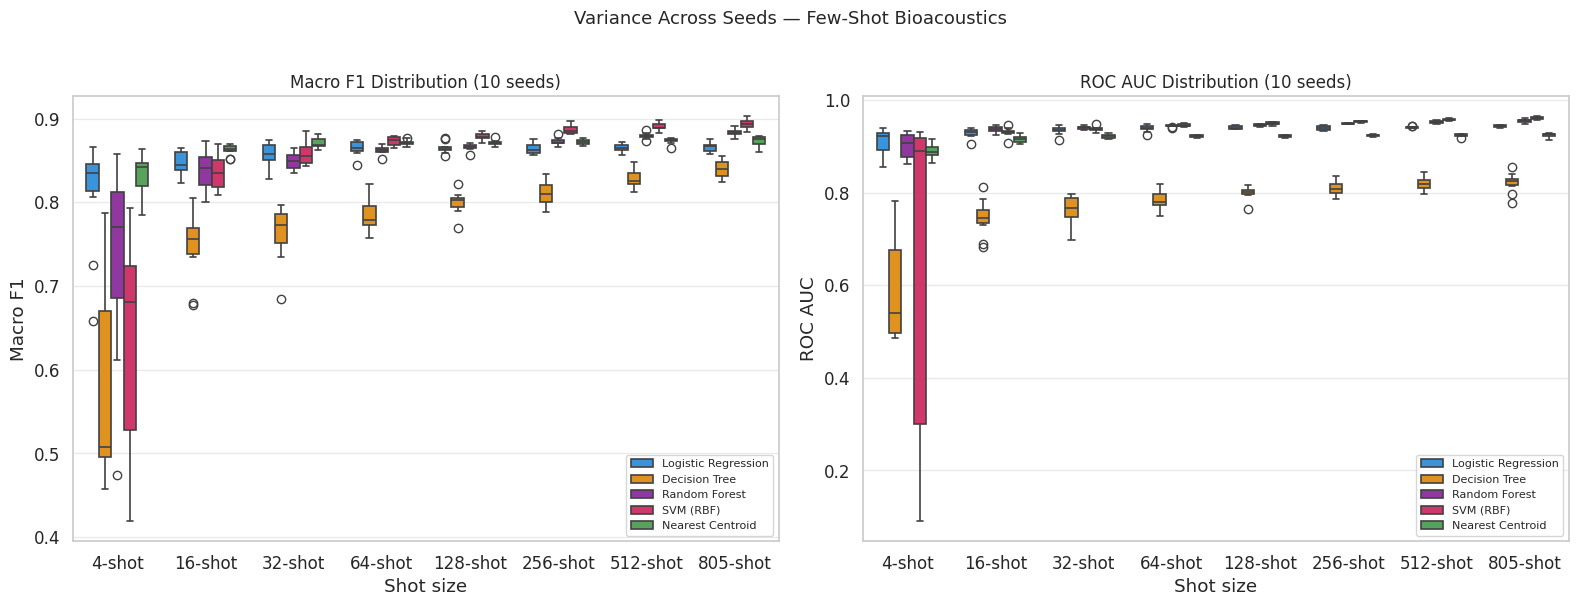

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/boxplots.png


In [62]:
# ── 6.3  Box plots of F1 distribution across seeds (all shots, all clfs) ─────
long_rows = []
for n_shots in SHOT_SIZES:
    for clf_name in clf_names:
        for trial in records[n_shots][clf_name]:
            long_rows.append({
                'n_shots'   : f'{n_shots}-shot',
                'classifier': clf_name,
                'macro_f1'  : trial['macro_f1'],
                'roc_auc'   : trial['roc_auc'],
            })
long_df = pd.DataFrame(long_rows)

# Ensure shot order is correct
shot_order = [f'{s}-shot' for s in SHOT_SIZES]
long_df['n_shots'] = pd.Categorical(long_df['n_shots'], categories=shot_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(
    axes,
    ['macro_f1', 'roc_auc'],
    ['Macro F1', 'ROC AUC']
):
    sns.boxplot(
        data=long_df, x='n_shots', y=metric, hue='classifier',
        palette=CLF_COLORS, ax=ax, linewidth=1.2, width=0.7
    )
    ax.set_title(f'{title} Distribution (10 seeds)', fontsize=12)
    ax.set_xlabel('Shot size')
    ax.set_ylabel(title)
    ax.legend(title='', fontsize=8, loc='lower right')
    ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Variance Across Seeds — Few-Shot Bioacoustics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/boxplots.png')

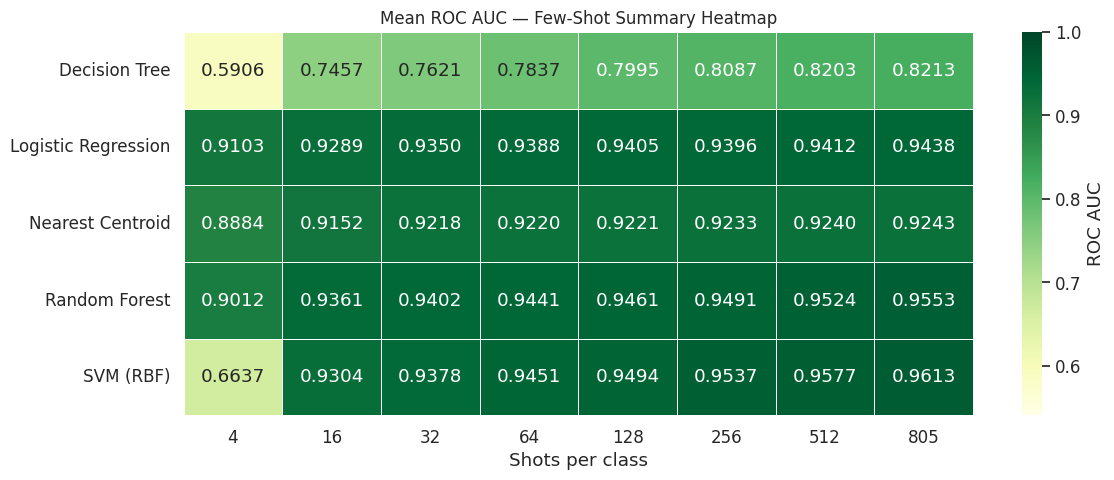

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/heatmap_auc.png


In [63]:
# ── 6.4  Heatmap: mean ROC AUC  (clf × shot size) ───────────────────────────
heatmap_data = summary_df.pivot(
    index='classifier', columns='n_shots', values='roc_auc_mean'
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
    vmin=heatmap_data.values.min() - 0.05, vmax=1.0, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'ROC AUC'}
)
ax.set_title('Mean ROC AUC — Few-Shot Summary Heatmap', fontsize=12)
ax.set_xlabel('Shots per class')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/heatmap_auc.png')

## 7 · Detailed Report at Best Shot Size Reported to Shot Size

Full classification report + confusion matrix for 16-shot (best seed)


─── Logistic Regression (16-shot, seed 0) ───
              precision    recall  f1-score   support

  background       0.97      0.83      0.90      2124
     whistle       0.75      0.95      0.84      1134

    accuracy                           0.87      3258
   macro avg       0.86      0.89      0.87      3258
weighted avg       0.89      0.87      0.88      3258


─── Decision Tree (16-shot, seed 0) ───
              precision    recall  f1-score   support

  background       0.89      0.81      0.85      2124
     whistle       0.69      0.81      0.75      1134

    accuracy                           0.81      3258
   macro avg       0.79      0.81      0.80      3258
weighted avg       0.82      0.81      0.81      3258


─── Random Forest (16-shot, seed 0) ───
              precision    recall  f1-score   support

  background       0.96      0.87      0.91      2124
     whistle       0.79      0.93      0.86      1134

    accuracy                           0.89      3258

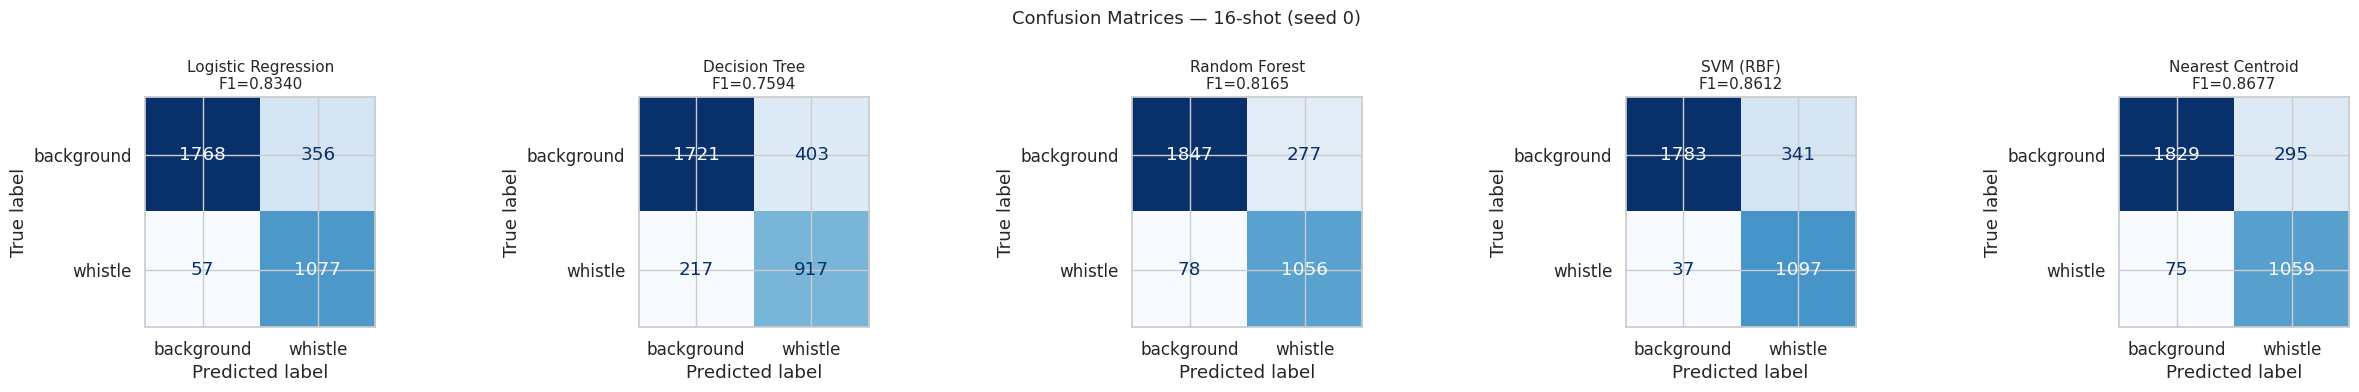

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/confusion.png


In [64]:
BEST_SHOTS = 16
REPORT_SEED = 0

clfs = make_classifiers()
trial_results = run_trial(X_norm, y, BEST_SHOTS, REPORT_SEED, clfs)

# Re-run to get predictions (run_trial only returns metrics now)
rng = np.random.RandomState(REPORT_SEED)
train_idx, test_idx = [], []
for cls in range(len(classes)):
    cls_idx = np.where(y == cls)[0]
    chosen = rng.choice(cls_idx, size=BEST_SHOTS, replace=False)
    train_idx.extend(chosen)
    test_idx.extend([i for i in cls_idx if i not in set(chosen)])

scaler_rep = StandardScaler()
X_tr_rep = scaler_rep.fit_transform(X_norm[train_idx])
X_te_rep = scaler_rep.transform(X_norm[test_idx])
y_tr_rep = y[train_idx]
y_te_rep = y[test_idx]

# Get predictions from each classifier
y_preds = {}
for name, clf in clfs.items():
    clf.fit(X_tr_rep, y_tr_rep)
    y_preds[name] = clf.predict(X_te_rep)

# Plot confusion matrices
n_clfs = len(clfs)
fig, axes = plt.subplots(1, n_clfs, figsize=(5 * n_clfs, 4))

for ax, clf_name in zip(axes, clfs.keys()):
    cm = confusion_matrix(y_te_rep, y_preds[clf_name])
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1 = trial_results[clf_name]['macro_f1']
    ax.set_title(f'{clf_name}\nF1={f1:.4f}', fontsize=11)

    print(f'\n─── {clf_name} ({BEST_SHOTS}-shot, seed {REPORT_SEED}) ───')
    print(classification_report(y_te_rep, y_preds[clf_name], target_names=classes))

plt.suptitle(f'Confusion Matrices — {BEST_SHOTS}-shot (seed {REPORT_SEED})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/confusion.png')

## 8 · Efficiency — F1 Gain per Additional Sample

=== ROC AUC Gain per Shot Step ===
  Decision Tree
    4→16 shots: +0.1551 AUC
    16→32 shots: +0.0164 AUC
    32→64 shots: +0.0215 AUC
    64→128 shots: +0.0158 AUC
    128→256 shots: +0.0092 AUC
    256→512 shots: +0.0116 AUC
    512→805 shots: +0.0011 AUC
  Logistic Regression
    4→16 shots: +0.0186 AUC
    16→32 shots: +0.0061 AUC
    32→64 shots: +0.0038 AUC
    64→128 shots: +0.0017 AUC
    128→256 shots: -0.0009 AUC
    256→512 shots: +0.0016 AUC
    512→805 shots: +0.0027 AUC
  Nearest Centroid
    4→16 shots: +0.0267 AUC
    16→32 shots: +0.0066 AUC
    32→64 shots: +0.0001 AUC
    64→128 shots: +0.0001 AUC
    128→256 shots: +0.0012 AUC
    256→512 shots: +0.0007 AUC
    512→805 shots: +0.0003 AUC
  Random Forest
    4→16 shots: +0.0349 AUC
    16→32 shots: +0.0041 AUC
    32→64 shots: +0.0039 AUC
    64→128 shots: +0.0021 AUC
    128→256 shots: +0.0029 AUC
    256→512 shots: +0.0033 AUC
    512→805 shots: +0.0029 AUC
  SVM (RBF)
    4→16 shots: +0.2667 AUC
    16→32 shots:

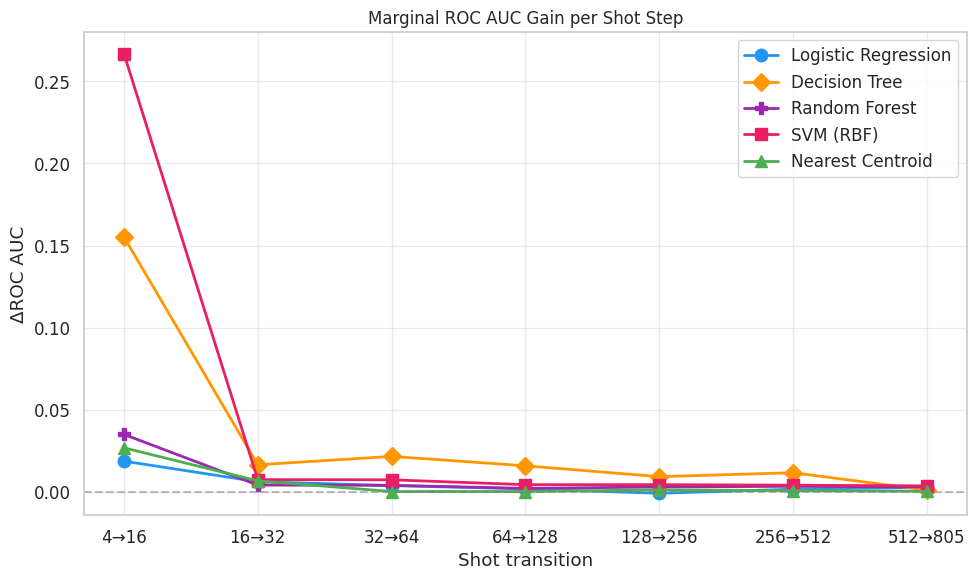

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/auc_gain.png


In [65]:
# ── 6.5  Marginal AUC gain per shot step ─────────────────────────────────────
auc_means = summary_df.pivot(
    index='classifier', columns='n_shots', values='roc_auc_mean'
)

print('=== ROC AUC Gain per Shot Step ===')
shot_pairs = list(zip(SHOT_SIZES, SHOT_SIZES[1:]))
for clf in auc_means.index:
    print(f'  {clf}')
    for s1, s2 in shot_pairs:
        gain = auc_means.loc[clf, s2] - auc_means.loc[clf, s1]
        print(f'    {s1}→{s2} shots: {gain:+.4f} AUC')

# Plot efficiency curves
fig, ax = plt.subplots(figsize=(10, 6))
for clf_name in clf_names:
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')
    gains = [
        auc_means.loc[clf_name, s2] - auc_means.loc[clf_name, s1]
        for s1, s2 in shot_pairs
    ]
    x_labels = [f'{s1}→{s2}' for s1, s2 in shot_pairs]
    ax.plot(x_labels, gains, marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=9)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Marginal ROC AUC Gain per Shot Step', fontsize=12)
ax.set_xlabel('Shot transition')
ax.set_ylabel('ΔROC AUC')
ax.legend(frameon=True, loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/auc_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/auc_gain.png')

## 9 · Timing Comparison

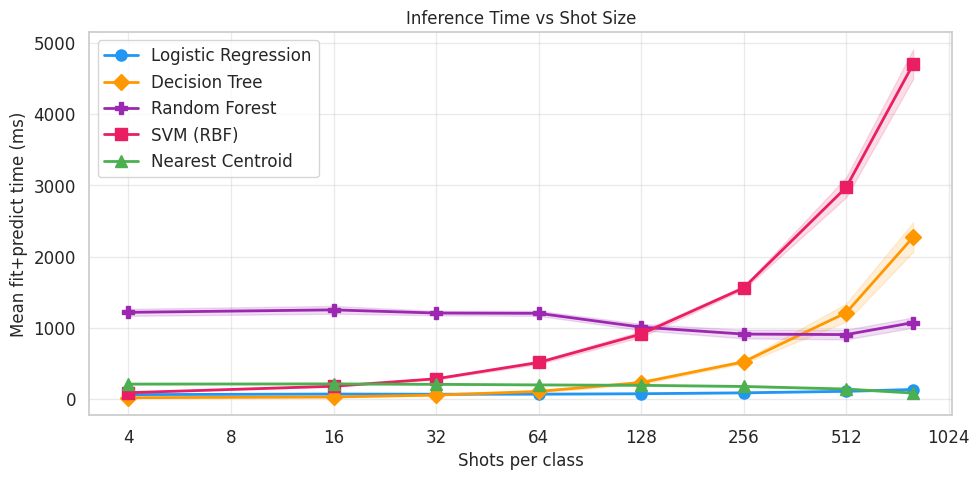

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/timing.png


In [66]:
# ── 6.6  Inference time vs shot size ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for clf_name in clf_names:
    sub = summary_df[summary_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['time_mean'] * 1000, marker=marker,
            color=color, label=clf_name, linewidth=2, markersize=8)
    ax.fill_between(sub.n_shots.values,
                    ((sub['time_mean'] - sub['time_std']) * 1000).values,
                    ((sub['time_mean'] + sub['time_std']) * 1000).values,
                    alpha=0.15, color=color)

ax.set_xlabel('Shots per class', fontsize=12)
ax.set_ylabel('Mean fit+predict time (ms)', fontsize=12)
ax.set_title('Inference Time vs Shot Size', fontsize=12)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend(frameon=True, loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/timing.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/timing.png')

## 10 · Conclusions

Compare few-shot best vs full-dataset results.

PREDICTIVE POWER RETENTION — % of 805-shot ROC AUC (≈ fully supervised)
n_shots               4     16    32    64    128   256    512    805
classifier                                                           
Decision Tree        71.9  90.8  92.8  95.4  97.3  98.5   99.9  100.0
Logistic Regression  96.4  98.4  99.1  99.5  99.7  99.6   99.7  100.0
Nearest Centroid     96.1  99.0  99.7  99.7  99.8  99.9  100.0  100.0
Random Forest        94.3  98.0  98.4  98.8  99.0  99.3   99.7  100.0
SVM (RBF)            69.0  96.8  97.6  98.3  98.8  99.2   99.6  100.0


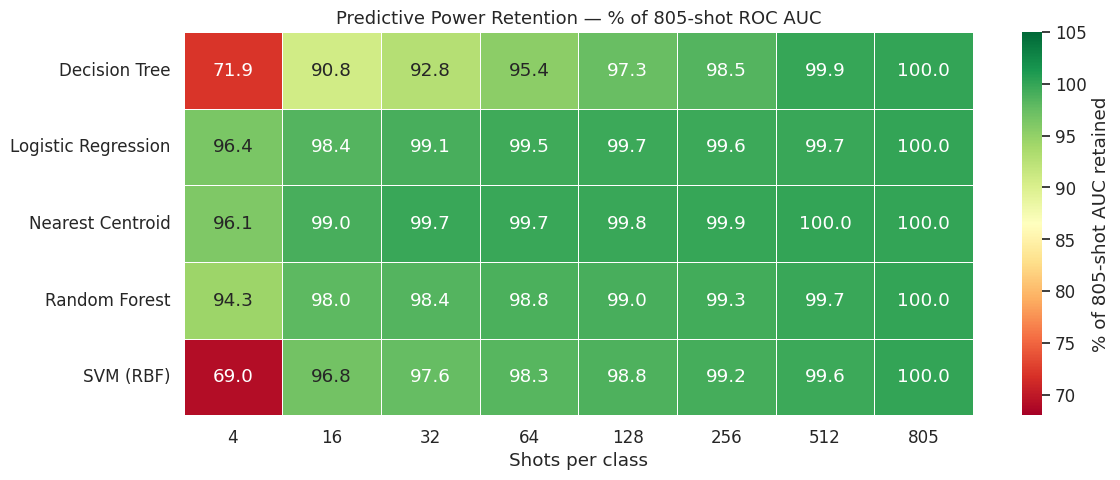

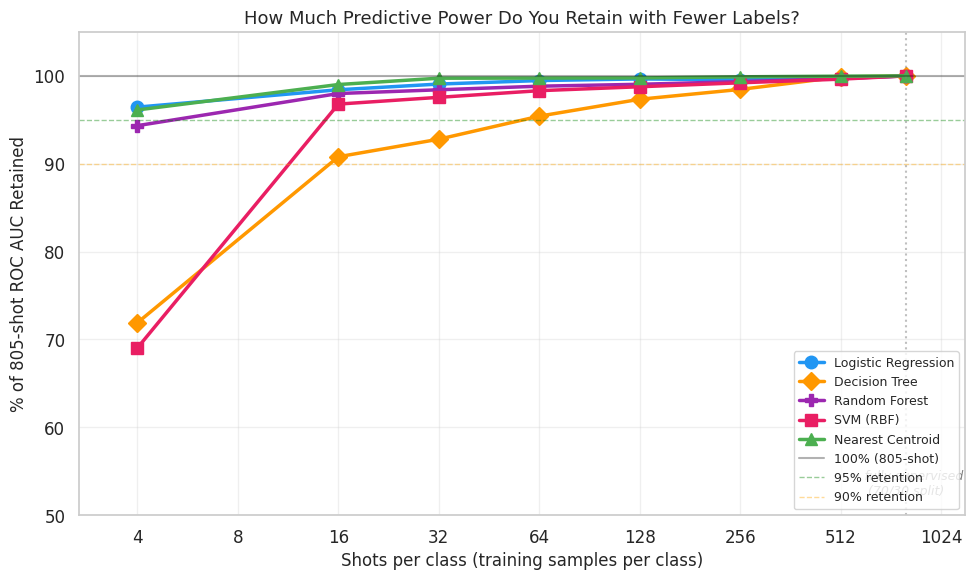

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/retention_curves_auc.png

── Key Takeaways ──
  Logistic Regression        90% retention at: 4-shot  |  95% retention at: 4-shot
  Decision Tree              90% retention at: 16-shot  |  95% retention at: 64-shot
  Random Forest              90% retention at: 4-shot  |  95% retention at: 16-shot
  SVM (RBF)                  90% retention at: 16-shot  |  95% retention at: 16-shot
  Nearest Centroid           90% retention at: 4-shot  |  95% retention at: 4-shot

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/retention_heatmap_auc.png
Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/retention_curves_auc.png


In [71]:
#@title Predictive power retention — % of max ROC AUC retained per shot size

# ── Compute retention using largest shot size as reference ─────────────────────
max_shot = SHOT_SIZES[-1]

retention_rows = []
for clf_name in clf_names:
    # Use the largest shot size as the "full" reference
    ref_row = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots == max_shot)]
    full_auc = ref_row['roc_auc_mean'].values[0]
    
    for n_shots in SHOT_SIZES:
        row = summary_df[(summary_df.classifier == clf_name) & (summary_df.n_shots == n_shots)]
        few_auc = row['roc_auc_mean'].values[0]
        few_std = row['roc_auc_std'].values[0]
        retention = (few_auc / full_auc) * 100
        retention_std = (few_std / full_auc) * 100
        retention_rows.append({
            'classifier': clf_name,
            'n_shots': n_shots,
            'few_auc': few_auc,
            'full_auc': full_auc,
            'retention_pct': retention,
            'retention_std': retention_std,
        })

ret_df = pd.DataFrame(retention_rows)
ret_df['retention_pct'] = ret_df['retention_pct'].clip(upper=100)

# ── Print table ───────────────────────────────────────────────────────────────
print('=' * 100)
print(f'PREDICTIVE POWER RETENTION — % of {max_shot}-shot ROC AUC (≈ fully supervised)')
print('=' * 100)
pivot = ret_df.pivot(index='classifier', columns='n_shots', values='retention_pct')
print(pivot.round(1).to_string())

# ── Plot 1: Retention heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
heatmap_data = ret_df.pivot(index='classifier', columns='n_shots', values='retention_pct')

sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=68, vmax=105, ax=ax, linewidths=0.5,
    cbar_kws={'label': f'% of {max_shot}-shot AUC retained'}
)
ax.set_title(f'Predictive Power Retention — % of {max_shot}-shot ROC AUC', fontsize=13)
ax.set_xlabel('Shots per class')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Retention curves with threshold lines ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for clf_name in clf_names:
    sub = ret_df[ret_df.classifier == clf_name].sort_values('n_shots')
    color = CLF_COLORS.get(clf_name, 'gray')
    marker = CLF_MARKERS.get(clf_name, 'o')

    ax.plot(sub.n_shots, sub['retention_pct'], marker=marker,
            color=color, label=clf_name, linewidth=2.5, markersize=9)

ax.axhline(100, color='black', linestyle='-', alpha=0.3, linewidth=1.5, label=f'100% ({max_shot}-shot)')
ax.axhline(95, color='green', linestyle='--', alpha=0.4, linewidth=1, label='95% retention')
ax.axhline(90, color='orange', linestyle='--', alpha=0.4, linewidth=1, label='90% retention')

ax.axvline(max_shot, color='gray', linestyle=':', alpha=0.5, linewidth=1.5)
ax.text(max_shot, 52, '≈ fully supervised\n(70/30 split)',
        ha='center', va='bottom', fontsize=9, color='gray', style='italic')

ax.set_xlabel('Shots per class (training samples per class)', fontsize=12)
ax.set_ylabel(f'% of {max_shot}-shot ROC AUC Retained', fontsize=12)
ax.set_title('How Much Predictive Power Do You Retain with Fewer Labels?', fontsize=13)
ax.set_xticks(SHOT_SIZES)
ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(SHOT_SIZES[0] / 1.5, SHOT_SIZES[-1] * 1.5)
ax.set_ylim(50, 105)
ax.legend(frameon=True, loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_curves_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/retention_curves_auc.png')

# ── Key takeaways ─────────────────────────────────────────────────────────────
print('\n── Key Takeaways ──')
for clf_name in clf_names:
    sub = ret_df[ret_df.classifier == clf_name]
    above_90 = sub[sub.retention_pct >= 90].n_shots.min()
    above_95 = sub[sub.retention_pct >= 95].n_shots.min()
    print(f'  {clf_name:<25s}  90% retention at: {above_90 if pd.notna(above_90) else f">{max_shot}"}-shot'
          f'  |  95% retention at: {above_95 if pd.notna(above_95) else f">{max_shot}"}-shot')

print(f'\nSaved: {BASE}/few_shot/retention_heatmap_auc.png')
print(f'Saved: {BASE}/few_shot/retention_curves_auc.png')

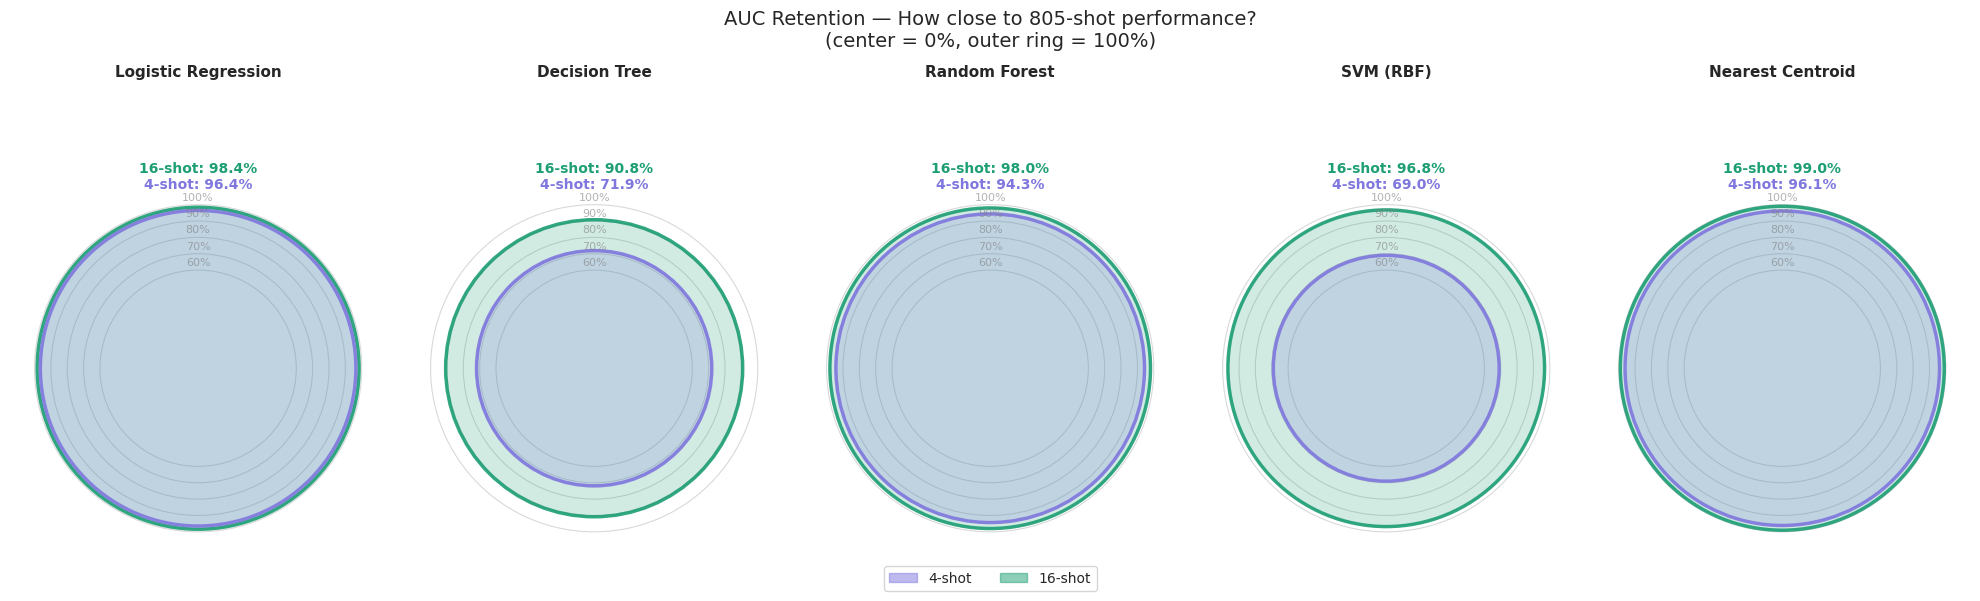

Saved: /data2/mromaniuc/cet-det/models/perch_v2/DOLPHINFREE/few_shot/retention_bullseye.png


In [76]:
#@title Bullseye retention chart — AUC retention at 4, 16, 256 shots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Shot sizes to compare
radar_shots = [4, 16]
shot_colors = ['#7F77DD', '#1D9E75']
shot_labels = ['4-shot', '16-shot']

max_shot = SHOT_SIZES[-1]

# Compute retention using max shot as reference
retention = {}
for s in radar_shots:
    retention[s] = []
    for clf in clf_names:
        ref_auc = summary_df[(summary_df.classifier == clf) & (summary_df.n_shots == max_shot)]['roc_auc_mean'].values[0]
        few_auc = summary_df[(summary_df.classifier == clf) & (summary_df.n_shots == s)]['roc_auc_mean'].values[0]
        retention[s].append(min((few_auc / ref_auc) * 100, 100))

n_clfs = len(clf_names)
fig, axes = plt.subplots(1, n_clfs, figsize=(4 * n_clfs, 5.5))

for ax, clf_idx, clf_name in zip(axes, range(n_clfs), clf_names):
    # Draw target rings
    for ring_pct in [60, 70, 80, 90, 100]:
        circle = plt.Circle((0, 0), ring_pct, fill=False, color='gray',
                            linewidth=0.8, alpha=0.3, linestyle='-')
        ax.add_patch(circle)
        ax.text(0, ring_pct + 1.5, f'{ring_pct}%', ha='center', va='bottom',
                fontsize=8, color='gray', alpha=0.6)

    # Draw filled arcs for each shot size (largest first so smaller ones are on top)
    for s, color, label in reversed(list(zip(radar_shots, shot_colors, shot_labels))):
        val = retention[s][clf_idx]
        circle_fill = plt.Circle((0, 0), val, color=color, alpha=0.2)
        circle_edge = plt.Circle((0, 0), val, fill=False, color=color, linewidth=2.5, alpha=0.9)
        ax.add_patch(circle_fill)
        ax.add_patch(circle_edge)

    # Value labels stacked at top, outside the circles
    y_start = 108
    for s, color, label in zip(radar_shots, shot_colors, shot_labels):
        val = retention[s][clf_idx]
        ax.text(0, y_start, f'{label}: {val:.1f}%', ha='center', va='bottom',
                fontsize=10, color=color, fontweight='bold')
        y_start += 10

    ax.set_xlim(-115, 115)
    ax.set_ylim(-115, 140)
    ax.set_aspect('equal')
    ax.set_title(clf_name, fontsize=11, fontweight='bold', pad=45)
    ax.axis('off')

# Shared legend
legend_patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
                  for c, l in zip(shot_colors, shot_labels)]
fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches),
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f'AUC Retention — How close to {max_shot}-shot performance?\n(center = 0%, outer ring = 100%)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(f'{BASE}/few_shot/retention_bullseye.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/few_shot/retention_bullseye.png')